# 01 — Data Cleaning

**Dataset:** UCI Bike Sharing — `hour.csv` (hourly rentals, 2011–2012)

**Goals:**
- Inspect raw data (shape, dtypes, sample rows)
- Identify and handle missing values
- Detect and decide on duplicates
- Detect and handle outliers
- Fix data types
- Save clean output to `data/processed/hour_clean.csv`

**Columns of interest:**
| Column | Description |
|--------|-------------|
| `dteday` | Date |
| `season` | 1=spring, 2=summer, 3=fall, 4=winter |
| `hr` | Hour (0–23) |
| `holiday` | Public holiday flag |
| `workingday` | Working day flag |
| `weathersit` | 1=clear, 2=mist, 3=light snow/rain, 4=heavy |
| `temp` | Normalised temperature |
| `atemp` | Normalised feels-like temperature |
| `hum` | Normalised humidity |
| `windspeed` | Normalised wind speed |
| `casual` | Casual user count |
| `registered` | Registered user count |
| `cnt` | **Target**: total rentals |

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itables import show #this is for displaying dataframes in a more interactive way in Jupyter notebooks
import sys
sys.path.append("..")
from src.utils import plot_missing, detect_outliers_iqr

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load & first look

In [22]:
df = pd.read_csv("../data/raw/hour.csv")
print(df.shape)
df.head()

(17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [24]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [25]:
show(df) #this comes from the itables library and allows us to display the dataframe in a more interactive way in Jupyter notebooks

Loading ITables v2.8.0 from the internet... (need help?)


## 2. Missing values

In [26]:
# TODO: check missing value counts and rates per column
# Hint: df.isnull().sum() and df.isnull().mean()
plot_missing(df)
df.isnull().sum() #this gives us the count of missing values per column
df.isnull().mean() #this gives us the percentage of missing values per column

No missing values.


instant       0.0
dteday        0.0
season        0.0
yr            0.0
mnth          0.0
hr            0.0
holiday       0.0
weekday       0.0
workingday    0.0
weathersit    0.0
temp          0.0
atemp         0.0
hum           0.0
windspeed     0.0
casual        0.0
registered    0.0
cnt           0.0
dtype: float64

## 3. Duplicates

In [27]:
# TODO: check for duplicate rows
# Consider: what makes a row logically unique? (dteday + hr)
print("Full duplicates:", df.duplicated().sum())
print("Date+hour duplicates:", df.duplicated(subset=["dteday", "hr"]).sum())

Full duplicates: 0
Date+hour duplicates: 0


Here we checked for duplicates in two ways: 
1. first we check if there are any fully duplicated rows. This could be because of merging datasets together and accidentally some rows from one happen to exist on the other, something like a timing overlap. 
2. Then, we understand what a duplicated row is defined by: the combination of a specific date, and an hour within that date. for that we use the subset argument inside the duplicated() method, which allows us to check for duplicates in combinations of columns. Then, we use the sum() method in both checks because we take advantage of the fact that duplicated() returns a boolean series (true is 1, false is 0 so summing them up over the entire series means we get the total number of duplicated rows)

## 4. Data types

In [28]:
# TODO: convert dteday to datetime, categorical columns to category dtype
# Categorical candidates: season, yr, mnth, hr, holiday, weekday, workingday, weathersit
df["dteday"] = pd.to_datetime(df["dteday"])
categorical_cols = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]
for col in categorical_cols:
    df[col] = df[col].astype("category")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  category      
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

## 5. Outlier detection

In [29]:
# TODO: check cnt, hum, windspeed for outliers via IQR and boxplots
# Decide: cap, remove, or keep with note?

<Axes: title={'center': 'cnt'}>

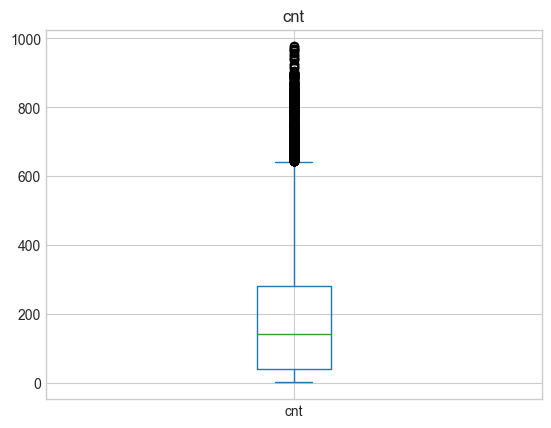

In [30]:
# this is the simplest way to do a boxplot
df['cnt'].plot(kind='box', title='cnt')

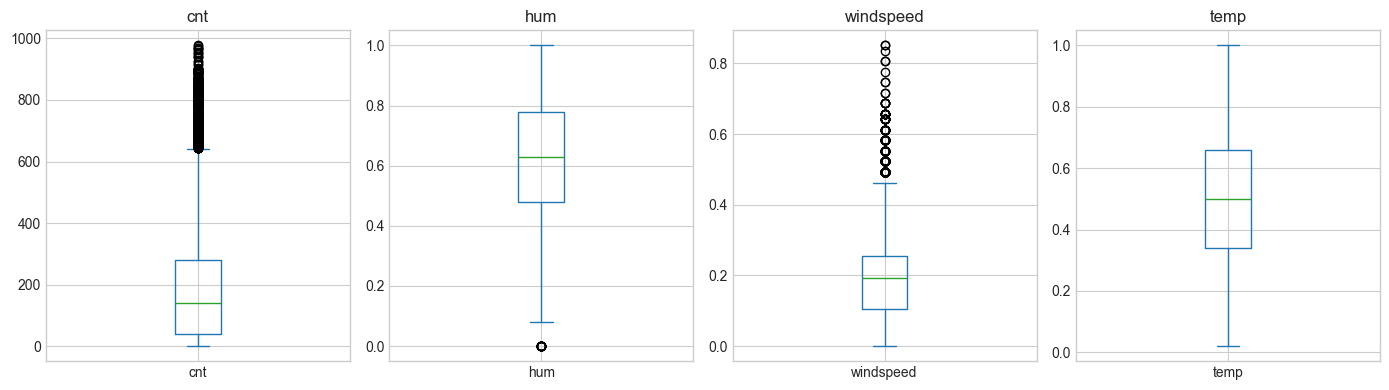

In [31]:
#what if we want to plot multiple boxplots in one figure?
#first we define the columns we want to plot
num_cols = ["cnt", "hum", "windspeed", "temp"]
#then we create a figure with subplots (this is an empty canvas with multiple areas to plot on)
fig, axes = plt.subplots(1, len(num_cols), figsize=(14, 4))
#then we loop through the columns and plot each one on a different subplot
for ax, col in zip(axes, num_cols):
    df[col].plot(kind="box", ax=ax, title=col)
#finally we adjust the layout so the titles don't overlap
plt.tight_layout()

fig,axes = plt.subplots(1,4) is the same as: 

result = plt.subplots(1, 4)
fig = result[0]
axes = result[1]

Without the zip notation: 
for i in range(len(num_cols)):
    df[num_cols[i]].plot(kind="box",ax=axes[i])

In [32]:
# IQR outlier flags — decide what to do with them
for col in ["cnt", "hum", "windspeed", "temp"]:
    flags = detect_outliers_iqr(df[col])
    print(f"{col}: {flags.sum()} outliers ({flags.mean():.1%})")

cnt: 505 outliers (2.9%)
hum: 22 outliers (0.1%)
windspeed: 342 outliers (2.0%)
temp: 0 outliers (0.0%)


## 6. Save cleaned data

In [33]:
# TODO: after all fixes, drop the 'instant' index column and save
df_clean = df.drop(columns=["instant"])
df_clean.to_csv("../data/processed/hour_clean.csv", index=False)
print(f"Saved {df_clean.shape[0]} rows to data/processed/hour_clean.csv")

Saved 17379 rows to data/processed/hour_clean.csv
